In [1]:
# imported important libraries for visualisation,numerical operations and table numerical operations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 11 # Make plots reasonably sized and readable by default
import seaborn as sns
# importing libraries for machine learning model
from sklearn.model_selection import train_test_split # for spliting, training and testing the model 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix


In [2]:
# upload of the data
path='Data Scientist Assignment.csv'
df=pd.read_csv(path)

In [3]:
# data profiling
df.head()

,PolicyID,Age,Gender,Occupation,IncomeBand,ProductType,Premium,PaymentFrequency,Channel,PolicyStartDate,TenureMonths,MissedPayments,PaymentDelayDays,LapseFlag,EarlyClaimFlag,ClaimAmount
0,POL1000,58,Female,Informal,Medium,Whole Life,2242823,Annual,Digital,2023-05-25 00:00:00,49,3,8,1,0,1985404
1,POL1001,48,Male,Unemployed,Low,Whole Life,1248173,Monthly,Agent,2022-11-29 00:00:00,1,2,0,0,1,5272544
2,POL1002,34,Male,Unemployed,Low,Endowment,1702025,Monthly,Bancassurance,2020-09-22 00:00:00,25,1,5,0,0,1859062
3,POL1003,62,Female,Unemployed,High,Term Life,2584833,Annual,Bancassurance,2022-01-31 00:00:00,51,2,22,1,0,2126861
4,POL1004,27,Male,Unemployed,Low,Whole Life,2791661,Annual,Bancassurance,2022-10-13 00:00:00,36,2,18,1,0,2051723


## Data preprocessing and removing possible available noise

In [4]:
# check for missing values
print(df.isnull().sum(),"missing values")
# no missing values found

PolicyID            0
Age                 0
Gender              0
Occupation          0
IncomeBand          0
ProductType         0
Premium             0
PaymentFrequency    0
Channel             0
PolicyStartDate     0
TenureMonths        0
MissedPayments      0
PaymentDelayDays    0
LapseFlag           0
EarlyClaimFlag      0
ClaimAmount         0
dtype: int64 missing values


In [5]:
# check for duplicates
print(df.duplicated().sum(), "duplicates")
# No duplicates found

0 duplicates


In [6]:
# Data profiling
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   PolicyID          500 non-null    object
 1   Age               500 non-null    int64 
 2   Gender            500 non-null    object
 3   Occupation        500 non-null    object
 4   IncomeBand        500 non-null    object
 5   ProductType       500 non-null    object
 6   Premium           500 non-null    int64 
 7   PaymentFrequency  500 non-null    object
 8   Channel           500 non-null    object
 9   PolicyStartDate   500 non-null    object
 10  TenureMonths      500 non-null    int64 
 11  MissedPayments    500 non-null    int64 
 12  PaymentDelayDays  500 non-null    int64 
 13  LapseFlag         500 non-null    int64 
 14  EarlyClaimFlag    500 non-null    int64 
 15  ClaimAmount       500 non-null    int64 
dtypes: int64(8), object(8)
memory usage: 62.6+ KB
None


In [7]:
# shape of the data
print("shape of the dataset",df.shape)

shape of the dataset (500, 16)


## Summary statistics

In [8]:
print(df.describe(include="all"))

       PolicyID         Age Gender Occupation IncomeBand ProductType  \
count       500  500.000000    500        500        500         500   
unique      500         NaN      2          4          3           3   
top     POL1000         NaN   Male   Informal        Low  Whole Life   
freq          1         NaN    266        131        177         176   
mean        NaN   44.864000    NaN        NaN        NaN         NaN   
std         NaN   14.315004    NaN        NaN        NaN         NaN   
min         NaN   20.000000    NaN        NaN        NaN         NaN   
25%         NaN   33.000000    NaN        NaN        NaN         NaN   
50%         NaN   45.000000    NaN        NaN        NaN         NaN   
75%         NaN   56.250000    NaN        NaN        NaN         NaN   
max         NaN   69.000000    NaN        NaN        NaN         NaN   

             Premium PaymentFrequency Channel      PolicyStartDate  \
count   5.000000e+02              500     500                  50

## Exploratory Data Analysis

In [9]:
# Overall base rates - these are our baseline to compare segments against.
print(f"Overall lapse rate:       {df['LapseFlag'].mean():.1%}")
print(f"Overall early claim rate: {df['EarlyClaimFlag'].mean():.1%}")

Overall lapse rate:       35.8%
Overall early claim rate: 13.8%


In [10]:
# For each categorical column, we compute the lapse rate and early-claim rate
# A category with a much higher/lower rate than the overall average is a candidate "risk driver"
categorical_cols = ['Gender', 'Occupation', 'IncomeBand', 'ProductType',
                     'PaymentFrequency', 'Channel']

for col in categorical_cols:
    print(f"\n {col}")
    summary = df.groupby(col)[['LapseFlag', 'EarlyClaimFlag']].mean().round(3)
    print(summary)
    print(df[col].value_counts())


 Gender
        LapseFlag  EarlyClaimFlag
Gender                           
Female      0.355           0.124
Male        0.361           0.150
Gender
Male      266
Female    234
Name: count, dtype: int64

 Occupation
               LapseFlag  EarlyClaimFlag
Occupation                              
Formal             0.317           0.167
Informal           0.374           0.084
Self-Employed      0.397           0.176
Unemployed         0.339           0.125
Occupation
Informal         131
Self-Employed    131
Formal           126
Unemployed       112
Name: count, dtype: int64

 IncomeBand
            LapseFlag  EarlyClaimFlag
IncomeBand                           
High            0.372           0.152
Low             0.305           0.158
Medium          0.403           0.101
IncomeBand
Low       177
High      164
Medium    159
Name: count, dtype: int64

 ProductType
             LapseFlag  EarlyClaimFlag
ProductType                           
Endowment        0.301           0.141
T

Interpretation.

Most variables(gender,Income band, Payment frequency, etc) show only small changes around the baselines which is nothing unusual.Channel is different as Digital has a 53.3% lapse rate, about 1.5 times the baseline. Meanwhile, Agent has a 32.0% early-claim rate more than double the baseline. These are large, consistent gaps across reasonably sized groups (152-181 policies each) hence not by chance and pointing to two distinct, channel-specific business problems.A lapse issue concentrated in Digital, and an early-claims issue concentrated in Agent. This means there is something in Digital channel that is causing spikes in the lapse rates and as well there is somethimg in the Agent channel that is causing early claims.

In [11]:
# Correlation of numeric variables with the two targets classes(Lapse flag and early claim flag)
numeric_cols = ['Age', 'Premium', 'TenureMonths', 'MissedPayments',
                 'PaymentDelayDays', 'ClaimAmount']

correlations = df[numeric_cols + ['LapseFlag', 'EarlyClaimFlag']].corr()
correlations[['LapseFlag', 'EarlyClaimFlag']]

,LapseFlag,EarlyClaimFlag
Age,-0.019445,0.404024
Premium,0.235960,0.061443
TenureMonths,0.055336,-0.199750
MissedPayments,0.732580,0.077116
PaymentDelayDays,-0.004854,-0.005672
ClaimAmount,0.017473,0.903689
LapseFlag,1.000000,0.003604
EarlyClaimFlag,0.003604,1.000000


Interpretation.

The correlation table shows how strongly each numeric variable moves together with Lapse flag and Early claim flag. For Lapse flag, missed payments stands out clearly with a correlation of 0.73 which by far the strongest relationship in the table confirming that payment behaviour is the dominant signal for predicting lapse, while all other variables (age, premium, tenure, payment delay days, claim amount) show weak correlations, suggesting they play only a minor role individually. For early claim flag, two variables stand out, claim amount with a correlation of 0.90 and age at 0.40. The extremely high correlation with claim amount reflects data leakage rather than a genuine predictive relationship, so it was excluded from modelling. Age, however, is a legitimate and meaningful signal, older policyholders are considerably more likely to experience an early claim, consistent with general insurance risk patterns. Tenure months shows a modest negative correlation (-0.20) with early claim flag, hinting that newer policies may carry somewhat higher early claim risk, a pattern explored further through the early tenure feature. Finally, the near-zero correlation (0.004) between lapse flag and early claim flag themselves indicates these are largely independent outcomes and therefore a policy lapsing tells us almost nothing about whether it is likely to have an early claim, and vice versa, so the two risks need to be modelled and addressed separately.

In [12]:
# Age distribution by early claim flag
print("Age by EarlyClaimFlag:")
print(df.groupby('EarlyClaimFlag')['Age'].describe())

Age by EarlyClaimFlag:
                count       mean        std   min   25%   50%   75%   max
EarlyClaimFlag                                                           
0               431.0  42.552204  13.587834  20.0  31.0  43.0  52.0  69.0
1                69.0  59.304348   9.527521  21.0  57.0  61.0  66.0  69.0


Interpretation.

Comparing the age profiles of policyholders with and without early claims reveals a clear pattern. Policyholders with no early claim have an average age of around 43, with most falling between their early 30s and early 50s. In contrast, policyholders who had an early claim have a typical age of around 59, with most concentrated between their late 50s and mid to late 60s. While both groups include some younger and older individuals at the extremes, the overall pattern is clear, early claims are heavily concentrated among older policyholders. This makes age a genuine and useful early-warning signal, so the model can legitimately use it to flag higher-risk policies before any claim occurs.

In [13]:
# Missed payments distribution by Lapse flag
print("\nMissedPayments by LapseFlag:")
print(df.groupby('LapseFlag')['MissedPayments'].describe())


MissedPayments by LapseFlag:
           count      mean       std  min  25%  50%  75%  max
LapseFlag                                                    
0          321.0  0.785047  0.711882  0.0  0.0  1.0  1.0  2.0
1          179.0  2.815642  1.177782  1.0  2.0  3.0  3.0  8.0


Interpretation.

Policies that did not lapse have an average of 0.79 missed payments (less than than 1 missed payment), with the majority (75%) having missed at most 1 payment, and a maximum of 2 payments missed. Policies that lapsed show a different pattern.They show an average of 2.82 missed payments (approximately 3 missed payments), with the minimum being 1 missed payment, the majority( 75%) having missed atleast 3 payments and a maximum number of missed payments as high as 8.This makes missed payments an extremely strong, reliable, and actionable early-warning signal as policies that begin missing payments are highly likely to eventually lapse, giving the business a clear, measurable trigger point for proactive intervention before the policy is lost entirely.


## Feature Engineering

In [14]:
df_features = df.copy()

# Derived flags for policies with more than 2 missed payments
# Derived flags for policies with 1 day plus payment delays 
df_features['MissedPaymentsflag'] = (df_features['MissedPayments'] >= 2).astype(int)
df_features['Paymentdelayflag'] = (df_features['PaymentDelayDays'] > 0).astype(int)

df_features['Paymentdelaybands'] = pd.cut(df_features['PaymentDelayDays'],bins=[-1, 0, 7, 15, 100],
                                         labels=['None', '1-7days', '8-15days', '16days+'])

print(df_features['MissedPaymentsflag'].value_counts()) 

print(df_features['Paymentdelaybands'].value_counts())

MissedPaymentsflag
0    280
1    220
Name: count, dtype: int64
Paymentdelaybands
16days+     245
8-15days    125
1-7days     116
None         14
Name: count, dtype: int64


In [15]:
# Flagging Tenure months to identify policies that are newer or older
# Feature engineering the tenure column into bands
df_features['EarlyTenure'] = (df_features['TenureMonths'] <= 12).astype(int)

df_features['Ageband'] = pd.cut(df_features['Age'],bins=[17, 30, 45, 60, 100],
    labels=['18-30', '31-45', '46-60', '60+'])
df_features[['EarlyTenure','Ageband']].value_counts()

EarlyTenure  Ageband
0            46-60      124
             31-45      117
             18-30       88
             60+         65
1            46-60       36
             31-45       32
             60+         22
             18-30       16
Name: count, dtype: int64

In [16]:
# Feature engeneering the premium column to identify low, high premium policy holders
df_features['Premiumband'] = pd.cut(df_features['Premium'],bins=[0, 500000, 1000000, 2000000, 3000000],
                                     labels = ['Micro <=500K', 'Low 500K-1M', 'Mid 1M-2M', 'High 2M-3M'])
df_features['Premiumband'].value_counts()

Premiumband
Mid 1M-2M       195
High 2M-3M      172
Low 500K-1M      77
Micro <=500K     56
Name: count, dtype: int64

In [17]:
# checking the new feature engineered columns
df_features[['Paymentdelaybands','Paymentdelayflag','MissedPaymentsflag','Ageband','Premiumband','EarlyTenure']].head()

,Paymentdelaybands,Paymentdelayflag,MissedPaymentsflag,Ageband,Premiumband,EarlyTenure
0,8-15days,1,1,46-60,High 2M-3M,0
1,None,0,1,46-60,Mid 1M-2M,1
2,1-7days,1,0,31-45,Mid 1M-2M,0
3,16days+,1,1,60+,High 2M-3M,0
4,16days+,1,1,18-30,High 2M-3M,0


In [18]:
# One hot encoding categorical variables for prediction
cat_cols_to_encode = ['Gender', 'Occupation', 'IncomeBand', 'ProductType', 'PaymentFrequency',
    'Channel', 'Ageband', 'Premiumband', 'Paymentdelaybands']
df_model = pd.get_dummies(df_features, columns=cat_cols_to_encode, drop_first=True)

print("Original shape:", df_features.shape)
print("Encoded shape: ", df_model.shape)
df_model.head()

Original shape: (500, 22)
Encoded shape:  (500, 33)


,PolicyID,Age,Premium,PolicyStartDate,TenureMonths,MissedPayments,PaymentDelayDays,LapseFlag,EarlyClaimFlag,ClaimAmount,...,Channel_Digital,Ageband_31-45,Ageband_46-60,Ageband_60+,Premiumband_Low 500K-1M,Premiumband_Mid 1M-2M,Premiumband_High 2M-3M,Paymentdelaybands_1-7days,Paymentdelaybands_8-15days,Paymentdelaybands_16days+
0,POL1000,58,2242823,2023-05-25 00:00:00,49,3,8,1,0,1985404,...,True,False,True,False,False,False,True,False,True,False
1,POL1001,48,1248173,2022-11-29 00:00:00,1,2,0,0,1,5272544,...,False,False,True,False,False,True,False,False,False,False
2,POL1002,34,1702025,2020-09-22 00:00:00,25,1,5,0,0,1859062,...,False,True,False,False,False,True,False,True,False,False
3,POL1003,62,2584833,2022-01-31 00:00:00,51,2,22,1,0,2126861,...,False,False,False,True,False,False,True,False,False,True
4,POL1004,27,2791661,2022-10-13 00:00:00,36,2,18,1,0,2051723,...,False,False,False,False,False,False,True,False,False,True


## Lapse prediction using Logistic regression model

In [19]:
# Define features to use in the model
exclude_cols = ['PolicyID', 'PolicyStartDate', 'LapseFlag', 'EarlyClaimFlag','ClaimAmount', 'MissedPayments', 'PaymentDelayDays']

feature_cols = [c for c in df_model.columns if c not in exclude_cols]

# Remove any remaining engineered features that may affect the model
leak_features = ['HighMissedPayments','HasPaymentDelay','PaymentDelayBand_1-7d','PaymentDelayBand_8-15d','PaymentDelayBand_16d+']
feature_cols = [c for c in feature_cols if c not in leak_features]

# Keep only numeric columns
numeric_feature_cols = [col for col in feature_cols if pd.api.types.is_numeric_dtype(df_model[col])]

feature_cols = numeric_feature_cols

print(f"Number of features used: {len(feature_cols)}")
print("Final features:", feature_cols)

Number of features used: 26
Final features: ['Age', 'Premium', 'TenureMonths', 'MissedPaymentsflag', 'Paymentdelayflag', 'EarlyTenure', 'Gender_Male', 'Occupation_Informal', 'Occupation_Self-Employed', 'Occupation_Unemployed', 'IncomeBand_Low', 'IncomeBand_Medium', 'ProductType_Term Life', 'ProductType_Whole Life', 'PaymentFrequency_Monthly', 'Channel_Bancassurance', 'Channel_Digital', 'Ageband_31-45', 'Ageband_46-60', 'Ageband_60+', 'Premiumband_Low 500K-1M', 'Premiumband_Mid 1M-2M', 'Premiumband_High 2M-3M', 'Paymentdelaybands_1-7days', 'Paymentdelaybands_8-15days', 'Paymentdelaybands_16days+']


In [20]:
# Segregating the X and y 
X = df_model[feature_cols].copy().astype(float)
y_lapse = df_model['LapseFlag']

# Train/test and split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_lapse, test_size=0.25, random_state=42, stratify=y_lapse)
# stratify=y ensures the train and test sets have similar proportions of
# lapsed and non lapsed policies (important with imbalanced classes)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# Training the model
lapse_model = LogisticRegression(max_iter=2000,class_weight='balanced',random_state=42)
lapse_model.fit(X_train_scaled, y_train)

# Model evaluation
y_pred = lapse_model.predict(X_test_scaled)
y_prob = lapse_model.predict_proba(X_test_scaled)[:, 1]

print("AUC-ROC:", round(roc_auc_score(y_test, y_prob), 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

AUC-ROC: 0.979

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92        80
           1       0.81      0.96      0.88        45

    accuracy                           0.90       125
   macro avg       0.89      0.92      0.90       125
weighted avg       0.91      0.90      0.91       125


Confusion Matrix:
[[70 10]
 [ 2 43]]


Developed a logistic regression model to predict policy lapse using numerical features with class imbalance handled through class weighting. The model demonstrated strong predictive performance on the test data, achieving an AUC-ROC of 0.979 and an overall accuracy of 90%. The results indicate high discriminative ability, particularly in identifying lapse cases, with a recall of 0.96 for the positive class and only two missed lapse cases. Although the model produced a small number of false positives, overall performance suggests that it effectively captures key patterns associated with lapse behaviour in the dataset

In [22]:
lapse_coefs = pd.Series(lapse_model.coef_[0], index=feature_cols)
lapse_coefs_sorted = lapse_coefs.sort_values(key=abs, ascending=False)
print("Top drivers of lapse (standardized coefficients):")
print(lapse_coefs_sorted.head(15))

Top drivers of lapse (standardized coefficients):
MissedPaymentsflag          3.833577
Channel_Digital             1.856997
Premiumband_High 2M-3M      1.286787
Premiumband_Mid 1M-2M      -0.505502
Premium                     0.460173
Occupation_Self-Employed    0.302174
Paymentdelayflag            0.282004
TenureMonths                0.271120
Ageband_31-45              -0.227014
Channel_Bancassurance      -0.188017
IncomeBand_Low             -0.171117
Gender_Male                 0.148793
Premiumband_Low 500K-1M    -0.147873
Occupation_Informal         0.130308
EarlyTenure                -0.128120
dtype: float64


In [23]:
# Cross validation
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

# Define model
lapse_model = LogisticRegression(max_iter=2000,class_weight='balanced',random_state=42)

# Cross-validation (AUC-ROC)
cv_auc = cross_val_score(lapse_model,X_train_scaled,y_train,cv=5,scoring='roc_auc')

print("Cross-validation AUC scores:", cv_auc)
print("Mean AUC:", cv_auc.mean())

Cross-validation AUC scores: [0.95447531 0.98996914 0.97376543 0.97530864 0.95133438]
Mean AUC: 0.9689705796848653


Perfomed a 5-fold cross-validation to assess the stability and generalisability of the logistic regression model. The training data was split into five subsets, with the model trained and evaluated iteratively across each fold using the AUC-ROC metric. The results showed consistent performance across folds, with scores ranging closely and a mean AUC of approximately 0.969, indicating that the model is stable and not overly dependent on a single train-test split

## Lapse prediction using XGBoost

In [24]:
# importing the classifiers for XGBoost
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# develping the model
xgb_model = XGBClassifier(n_estimators=300,learning_rate=0.05,max_depth=4,subsample=0.8,colsample_bytree=0.8,random_state=42,eval_metric='logloss')

xgb_model.fit(X_train_scaled, y_train) # fiting the model

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [25]:
# Model evaluation
y_pred = xgb_model.predict(X_test_scaled)
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("AUC-ROC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

AUC-ROC: 0.9741666666666666

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.92        80
           1       0.85      0.87      0.86        45

    accuracy                           0.90       125
   macro avg       0.89      0.89      0.89       125
weighted avg       0.90      0.90      0.90       125


Confusion Matrix:
[[73  7]
 [ 6 39]]


The XGBoost model significantly improved predictive performance compared to logistic regression, achieving an AUC-ROC of 0.974 and an overall accuracy of 90%. The model demonstrated strong ability to identify lapse cases, with a recall of 0.87, indicating its effectiveness for early identification of at-risk policyholders. This improvement highlights the presence of nonlinear relationships between predictor variables and lapse behaviour

In [26]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("Top drivers of lapse (XGBoost feature importance):")
print(xgb_importance.head(15))

Top drivers of lapse (XGBoost feature importance):
MissedPaymentsflag            0.361062
Premiumband_High 2M-3M        0.094788
Channel_Digital               0.074051
Premium                       0.039388
Occupation_Unemployed         0.036036
Premiumband_Low 500K-1M       0.028689
Premiumband_Mid 1M-2M         0.028657
Occupation_Self-Employed      0.027334
Channel_Bancassurance         0.026552
Age                           0.023430
Paymentdelaybands_8-15days    0.022524
Ageband_46-60                 0.021583
IncomeBand_Low                0.021402
TenureMonths                  0.020147
Ageband_31-45                 0.019631
dtype: float32


The XGBoost model identified missed payments as the strongest predictor of policy lapse, followed by premium level and distribution channel. Customers with missed payments, higher premium bands(2M-3M), and those customers acquired through digital channels were more likely to lapse. Employment-related factors such as being unemployed or self-employed, as well as early signs of payment delays, also contributed to lapse risk. Overall, the results show that lapse behaviour is mainly driven by financial strain and payment behaviour, with additional influence from customer demographics and acquisition channel.

In [27]:
# cross validation of the model
from sklearn.model_selection import cross_val_score

cv_auc = cross_val_score(xgb_model,X_train_scaled,y_train,cv=5,scoring='roc_auc')

print("CV AUC scores:", cv_auc)
print("Mean CV AUC:", cv_auc.mean())

CV AUC scores: [0.9529321  0.98842593 0.97762346 0.98070988 0.96232339]
Mean CV AUC: 0.9724029497839022


In [28]:
# Save for reporting
lapse_coefs_sorted.to_csv('lapse_coefs.csv')

## Early claim prediction using XGBoost

In [29]:
# Defined features for early claim risk prediction
exclude_cols = ['PolicyID', 'PolicyStartDate', 'LapseFlag', 'EarlyClaimFlag','ClaimAmount', 'Age', 'EarlyTenure']

feature_cols = [c for c in df_model.columns if c not in exclude_cols]

# Removed any delay-related features to avoid model from cheating
new_features = ['HighMissedPayments', 'HasPaymentDelay','PaymentDelayBand_1-7d', 'PaymentDelayBand_8-15d', 'PaymentDelayBand_16d+']
feature_cols = [c for c in feature_cols if c not in new_features]

# Keep only numeric columns
numeric_feature_cols = [col for col in feature_cols if pd.api.types.is_numeric_dtype(df_model[col])]

feature_cols = numeric_feature_cols

print(f"Number of features used: {len(feature_cols)}")
print("Final features for Early Claim:", feature_cols)

Number of features used: 26
Final features for Early Claim: ['Premium', 'TenureMonths', 'MissedPayments', 'PaymentDelayDays', 'MissedPaymentsflag', 'Paymentdelayflag', 'Gender_Male', 'Occupation_Informal', 'Occupation_Self-Employed', 'Occupation_Unemployed', 'IncomeBand_Low', 'IncomeBand_Medium', 'ProductType_Term Life', 'ProductType_Whole Life', 'PaymentFrequency_Monthly', 'Channel_Bancassurance', 'Channel_Digital', 'Ageband_31-45', 'Ageband_46-60', 'Ageband_60+', 'Premiumband_Low 500K-1M', 'Premiumband_Mid 1M-2M', 'Premiumband_High 2M-3M', 'Paymentdelaybands_1-7days', 'Paymentdelaybands_8-15days', 'Paymentdelaybands_16days+']


In [30]:
# Organising the X and y for early claim prediction
X = df_model[feature_cols].copy().astype(float)
y_early = df_model['EarlyClaimFlag']

# Train test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y_early, test_size=0.25, random_state=42, stratify=y_early)

# Usually XGBoost does not need scaling, but i decided to keep it for consistency
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Training XGBoost with regularization to reduce overfitting
early_claim_model = XGBClassifier(n_estimators=200,learning_rate=0.05,max_depth=4,
                    subsample=0.8,colsample_bytree=0.8,reg_alpha=1.0,reg_lambda=1.0,
                    random_state=42,eval_metric='auc',scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])) # handle imbalance

# fitting the model
early_claim_model.fit(X_train_scaled, y_train)

# Model evaluation
y_pred = early_claim_model.predict(X_test_scaled)
y_prob = early_claim_model.predict_proba(X_test_scaled)[:, 1]

print("XGBoost AUC-ROC:", round(roc_auc_score(y_test, y_prob), 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

XGBoost AUC-ROC: 0.985

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       108
           1       0.82      0.82      0.82        17

    accuracy                           0.95       125
   macro avg       0.90      0.90      0.90       125
weighted avg       0.95      0.95      0.95       125


Confusion Matrix:
[[105   3]
 [  3  14]]


The XGBoost model developed for early claim prediction demonstrated strong predictive performance, achieving an AUC-ROC of 0.985 and an overall accuracy of 95%. The model showed a high level of balance in classification, correctly identifying both non-claim and early claim cases with strong precision and recall. Specifically, it achieved a recall of 0.82 for early claim cases, indicating that most early claims were successfully detected, with only a small number of missed cases. Overall, the results suggest that the model is highly effective at distinguishing between customers likely and unlikely to make early claims, making it suitable for early risk identification and intervention.

In [32]:
# cross validation
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(early_claim_model, X, y_early, cv=cv, scoring='roc_auc')

print("Cross-Validation AUC scores:", scores)
print("Mean CV AUC:", round(scores.mean(), 3))
print("Std CV AUC:", round(scores.std(), 3))

Cross-Validation AUC scores: [0.98054819 0.97259136 0.96179402 0.99252492 0.93687708]
Mean CV AUC: 0.969
Std CV AUC: 0.019


The early claim XGBoost model was further validated using 5-fold cross-validation to assess its stability and generalisation performance. The model achieved consistently high AUC-ROC scores across folds, ranging from 0.937 to 0.993, with a mean AUC of 0.969 and a low standard deviation of 0.019. This indicates strong and stable predictive performance across different data splits, suggesting that the model is not overly dependent on a single train-test partition. Overall, the results confirm that the model is both accurate and robust in identifying customers likely to make early claims.

### Business Insights

In [33]:
print("Overall portfolio")
print(f"Total policies:            {len(df_features)}")
print(f"Lapse rate:                {df_features['LapseFlag'].mean():.1%}")
print(f"Early claim rate:          {df_features['EarlyClaimFlag'].mean():.1%}")
print(f"Total annualized premium:  {df_features['Premium'].sum():,.0f}")

Overall portfolio
Total policies:            500
Lapse rate:                35.8%
Early claim rate:          13.8%
Total annualized premium:  800,884,454


In [34]:
early_claims_total = df_features.loc[df_features['EarlyClaimFlag'] == 1, 'ClaimAmount'].sum()
print(f"Total early-claim payouts: {early_claims_total:,.0f}")

avg_early = df_features.loc[df_features['EarlyClaimFlag'] == 1, 'ClaimAmount'].mean()
avg_other = df_features.loc[df_features['EarlyClaimFlag'] == 0, 'ClaimAmount'].mean()
print(f"Avg claim - early claims:  {avg_early:,.0f}")
print(f"Avg claim - other:         {avg_other:,.0f}")

Total early-claim payouts: 856,171,005
Avg claim - early claims:  12,408,275
Avg claim - other:         1,500,372


1. Portfolio scale. The dataset covers 500 policies generating a combined UGX 800,884,454 in annualized premium. This figure represents the total revenue base of the portfolio and serves as the benchmark against which all at risk amounts (premium lost to lapse, claims paid on early claims, etc.) should be compared to understand their relative scale.
2. Lapse affects over a third of the portfolio
35.8% of policies (179 out of 500) have lapsed. This is a substantial proportion as it means more than one in three policies sold eventually stops being active. Given that lapse was found to be almost entirely predictable from missed payments, this represents a large pool of potentially preventable attrition, making retention a high-priority operational focus.
3. Early claims are less frequent but far more severe
13.8% of policies (69 out of 500) experienced an early claim. While this affects a smaller share of the portfolio than lapse, the financial consequences per incident are far more serious, as shown in the next points.
4. Early claims cost 8.3 more on average than other claims
The average claim amount for policies with an early claim is UGX 12,408,275, compared to UGX 1,500,372 for policies without an early claim which is a difference of roughly 8.3 times. This indicates that early claims aren't just claims that happen sooner, they tend to be substantially larger payouts, likely reflecting higher-severity events (like major health issues or large sum-assured policies triggering claims shortly after policy inception).
5. Total early-claim payouts exceed the portfolio's annual premium income
Across the 69 policies with early claims, total payouts amount to UGX 856,171,005 which is actually higher than the entire portfolio's annualized premium of UGX 800,884,454. In other words, the cumulative cost of early claims alone exceeds what the whole portfolio brings in in premium over a year.

6. Together, these numbers suggest two distinct but equally important risk areas.Lapse is a high-frequency, lower-severity problem (many policies, each representing modest lost premium), while early claims are a low-frequency, high-severity problem (fewer policies, but each carrying a disproportionately large cost). Both require attention, but the interventions differ. Lapse calls for proactive retention or payment-support measures to customers, while early claims call for stronger underwriting and risk-based pricing at the point of sale (particularly for the older-age and clients brough in through Agents-channel.

In [35]:
# How lapse rate escalates with the number of missed payments.
print("Lapse rate by number of missed payments:")
print(df_features.groupby('MissedPayments')['LapseFlag'].agg(['mean', 'count']))

print("Lapse rate by Channel")
print(df_features.groupby('Channel')['LapseFlag'].agg(['mean', 'count']))

print("\nPremium tied up in lapsed policies, by channel")
print(df_features[df_features['LapseFlag'] == 1].groupby('Channel')['Premium'].sum())

print("Early claim rate by Age band")
print(df_features.groupby('Ageband', observed=True)['EarlyClaimFlag'].agg(['mean', 'count']))

print("\nEarly claim rate by Channel")
print(df_features.groupby('Channel')['EarlyClaimFlag'].agg(['mean', 'count']))

print("\nEarly claim rate by policy tenure (first 12 months vs older)")
print(df_features.groupby('EarlyTenure')['EarlyClaimFlag'].agg(['mean', 'count']))


Lapse rate by number of missed payments:
                    mean  count
MissedPayments                 
0               0.000000    123
1               0.082803    157
2               0.564516    124
3               1.000000     57
4               1.000000     22
5               1.000000     12
6               1.000000      4
8               1.000000      1
Lapse rate by Channel
                   mean  count
Channel                       
Agent          0.281768    181
Bancassurance  0.256579    152
Digital        0.532934    167

Premium tied up in lapsed policies, by channel
Channel
Agent            102396667
Bancassurance     77239000
Digital          151858756
Name: Premium, dtype: int64
Early claim rate by Age band
             mean  count
Ageband                 
18-30    0.019231    104
31-45    0.020134    149
46-60    0.175000    160
60+      0.413793     87

Early claim rate by Channel
                   mean  count
Channel                       
Agent          0.320442    

1. Lapse rate by missed payments.
Policies with 0 missed payments (123 policies) have a 0% lapse rate i.e, none of them lapsed. Policies with 1 missed payment (157 policies), lapse rate is still very low at 8.3%. But at 2 missed payments (124 policies), lapse rate jumps dramatically to 56.5%. From 3 missed payments onward (96 policies), lapse rate is exactly 100%. Meaning every single one of these policies lapsed, regardless of whether they missed 3, 4, 5, 6, or even 8 payments. This confirms missed payments as an almost deterministic trigger. 2 missed payments is the critical tipping point where the business should intervene, and 3+ missed payments is effectively a point of no return.

2. Lapse rate and premium at risk by channel (digital is the outlier).
Digital has a 53.3% lapse rate (167 policies) which is roughly double Agent (28.2%, 181 policies) and Bancassurance (25.7%, 152 policies). In monetary terms, digital also has the highest premium tied up in lapsed policies at UGX 151,858,756, compared to UGX 102,396,667 (agent) and UGX 77,239,000 (bancassurance). Even though digital doesn't have the most policies overall (digital has 167 while agent has 181), it contributes the most lapsed premium both because its lapse rate is highest and because the policies that do lapse appear to carry meaningful premium value. This makes digital the clear priority channel for the efforts to reduce lapse.

3. Early claim rate by age band (risk increases sharply with age).
The pattern here is a steady escalation as 18-30 year-olds (104 policies) have just a 1.9% early-claim rate, 31-45 year-olds (149 policies) are nearly identical at 2.0%, but 46-60 year-olds (160 policies) jump to 17.5% roughly 9 times higher than the younger groups. The 60+ band (87 policies) is highest at 41.4%, more than double the 46-60 group and over 20 times the rate of under-45s. This isn't a sudden cliff like the missed-payments pattern, it's a gradual but accelerating increase, with the steepest jump occurring after age 45. This suggests age-based underwriting adjustments could reasonably be tiered (e.g. standard rates under 45, moderate loading 46-60, significant loading or additional screening for 60+).

4.Early claim rate by channel (Agent is the clear outlier).
Agent has a 32.0% early-claim rate (181 policies) which is roughly 9-10 times higher than Bancassurance (3.3%, 152 policies) and Digital (3.6%, 167 policies), which are both close to each other and far below the portfolio average. Unlike the age pattern (which is gradual), this is a sharp, isolated outlier. Agent stands alone while the other two channels behave similarly to each other. This strongly suggests something specific to the Agent channel's of customer acquisition (sales practices, suitability assessments, incentive structures) rather than a general market-wide pattern.

5. Early claim rate by policy tenure (new policies are higher risk).
Policies in their first 12 months (EarlyTenure=1, 106 policies) have a 31.1% early-claim rate, compared to 9.1% for policies older than 12 months (EarlyTenure=0, 394 policies) which is about 3.4 times higher. This is consistent with anti-selection risk: customers who already suspect they'll need to claim soon may be more likely to take out a policy and claim shortly after, before underwriting controls or waiting periods have had time to filter them out.

Conclusion.

Two channels emerge as priority areas, but for different reasons and different outcomes: Digital drives lapse (53.3% rate, highest premium at risk), while Agent drives early claims (32.0% rate, approximatey 9 times the other channels). Separately, two clear thresholds emerge for proactive intervention: 2 missed payments as the lapse tipping point beyond which clients lapse with no turning back, and age 45+ combined with first-year tenure as early-claim risk indicators.

In [36]:
# Total premium at risk because the policy lapsed-revenue the business stops collecting once a policy lapses.
lapsed_premium = df_features.loc[df_features['LapseFlag'] == 1, 'Premium'].sum()
total_premium = df_features['Premium'].sum()

print(f"Premium tied to lapsed policies: {lapsed_premium:,.0f}")
print(f"As a share of total book:        {lapsed_premium / total_premium:.1%}")

Premium tied to lapsed policies: 331,494,423
As a share of total book:        41.4%


The company has collected UGX UGX 800,884,454 million in total yearly insurance premiums from all customers. However, not all of these customers continue paying.
Out of this money, about UGX 331,494,423 million (41%) comes from customers who have already stopped paying (lapsed). This is important because it shows that a big part of the company’s expected income is actually lost when customers leave.
Even though only about 36% of customers have lapsed, they account for a larger share of the money (41%). This means the company is losing more money from higher-paying customers, not just more customers.

The main reason this happens is missed payments. Customers who miss payments are very likely to eventually stop their policy. Also, customers who joined through digital channels are more likely to leave and contribute more to this loss.

Therefore,

A small group of customers is responsible for a large amount of lost money
Missed payments are the earliest warning sign
Digital customers are more likely to leave
If the company acts early when payments are missed, it can reduce a lot of this loss

## Data visualization with business insights

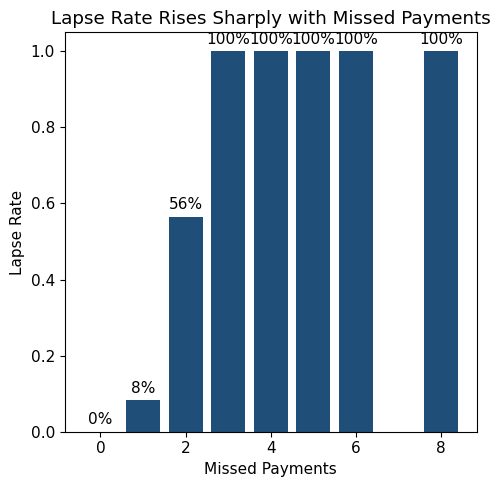

In [37]:
# Lapse rate with missed payments
fig, ax = plt.subplots(figsize=(5,5))
g = df_features.groupby('MissedPayments')['LapseFlag'].mean()
ax.bar(g.index, g.values, color='#1f4e79')
ax.set_xlabel('Missed Payments')
ax.set_ylabel('Lapse Rate')
ax.set_title('Lapse Rate Rises Sharply with Missed Payments')
for x, y in zip(g.index, g.values):
    ax.text(x, y + 0.02, f'{y:.0%}', ha='center')
plt.tight_layout()
plt.savefig('chart_lapse_missed.png', dpi=150)
plt.show()

### Key findings
0 missed payments: Customers who pay on time have an almost 0% lapse rate, indicating very low risk of policy lapse.

1 missed payment: The lapse rate increases to approximately 8%, suggesting the first missed payment is an early warning sign of potential lapse.

2 missed payments: The lapse rate rises sharply to about 56%, meaning more than half of these customers are likely to lapse.

3 or more missed payments: The lapse rate reaches 100% in this dataset, indicating that customers with repeated missed payments almost always lapse.

### Business Implications

Missed payments are the strongest indicator of future policy lapse.

The first missed payment provides an opportunity for intervention before the risk becomes critical.

Customers with two missed payments should be treated as high-risk, as the probability of lapse exceeds 50%.

Waiting until three or more payments are missed is often too late, as lapse becomes almost certain.

### Conclusion

The likelihood of policy lapse increases significantly with each missed payment, with risk becoming particularly severe after the second missed payment.**


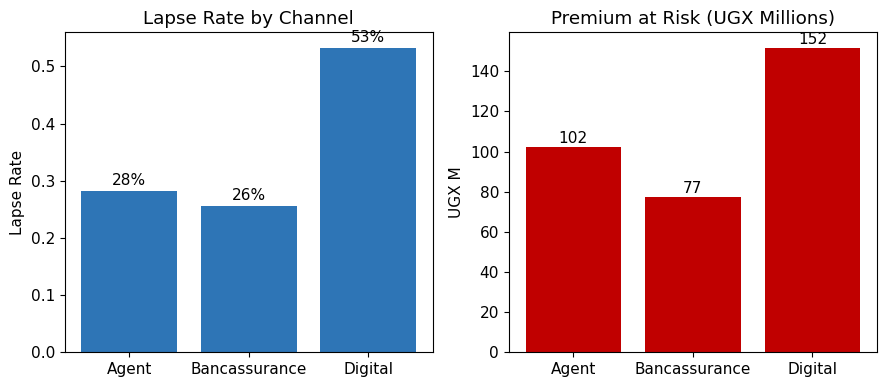

In [38]:
# Lapse rate by channel and premium at risk by channel
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

g = df_features.groupby('Channel')['LapseFlag'].mean()
axes[0].bar(g.index, g.values, color='#2e75b6')
axes[0].set_title('Lapse Rate by Channel')
axes[0].set_ylabel('Lapse Rate')
for i, (x, y) in enumerate(zip(g.index, g.values)):
    axes[0].text(i, y + 0.01, f'{y:.0%}', ha='center')

risk = df_features[df_features['LapseFlag'] == 1].groupby('Channel')['Premium'].sum() / 1e6
axes[1].bar(risk.index, risk.values, color='#c00000')
axes[1].set_title('Premium at Risk (UGX Millions)')
axes[1].set_ylabel('UGX M')
for i, (x, y) in enumerate(zip(risk.index, risk.values)):
    axes[1].text(i, y + 2, f'{y:,.0f}', ha='center')

plt.tight_layout()
plt.savefig('chart_channel.png', dpi=150)
plt.show()

### Key findings
Digital channel has the highest lapse rate (53%), meaning more than half of customers acquired through digital platforms eventually lapse.This means that more than 2 in 4 customers obtained through the digital channel eventually lapse.

Agent channel has a lapse rate of 28%, which is significantly lower than the digital channel but still represents a notable level of customer attrition.This means that 28% of customers acquired through Agent channel lapse compared to 53% from digital channel. Approximately 1 in 4 customers obtained through agent channel lapse. The 28% is below the baseline threshold of 35% meaning that agent customers retain their policies better than digital channel customers.

Bancassurance has the lowest lapse rate (26%), indicating that customers acquired through bank partnerships are the most likely to retain their policies as compared to agents and digital channels acquisition.26% of the customers obtained from bancassurance lapse which is the lowest.

The Digital channel also has the highest premium at risk (UGX 152 million), meaning it contributes the largest amount of lost premium income due to lapses.

The Agent channel accounts for UGX 102 million in premium at risk, making it the second-largest source of lost premium revenue.

Bancassurance has the lowest premium at risk (UGX 77 million), reflecting both its lower lapse rate and stronger customer retention.

### Business Implications

The Digital channel is the highest-risk distribution channel, combining both the highest lapse rate and the largest amount of premium loss.

Customer retention efforts should be prioritised in the Digital channel, as reducing lapses in this segment could recover a substantial amount of premium income.

Bancassurance appears to be the most stable channel, suggesting that practices used in this channel could be studied and applied to improve retention in other channels.

Designing specific channel retention strategies may be more effective than a standard retention approach for all customers from the different channels, given the large differences in lapse behaviour across channels.

### Conclusion

The Digital channel represents the greatest source of premium loss, with over half of its customers lapsing and approximately UGX 152 million in premium revenue at risk.


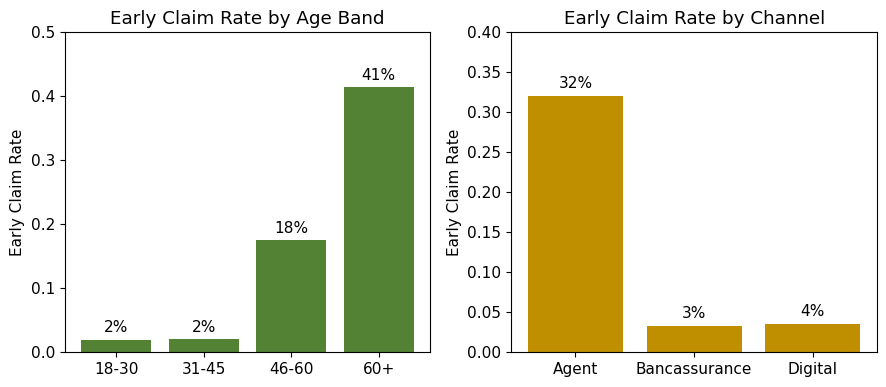

In [39]:
# Early claim rate by age band and by channel
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

g = df_features.groupby('Ageband', observed=True)['EarlyClaimFlag'].mean()
axes[0].bar(g.index.astype(str), g.values, color='#548235')
axes[0].set_title('Early Claim Rate by Age Band')
axes[0].set_ylabel('Early Claim Rate')
axes[0].set_ylim(0, 0.5)
for i, (x, y) in enumerate(zip(g.index, g.values)):
    axes[0].text(i, y + 0.012, f'{y:.0%}', ha='center')

g2 = df_features.groupby('Channel')['EarlyClaimFlag'].mean()
axes[1].bar(g2.index, g2.values, color='#bf8f00')
axes[1].set_title('Early Claim Rate by Channel')
axes[1].set_ylabel('Early Claim Rate')
axes[1].set_ylim(0, 0.4)
for i, (x, y) in enumerate(zip(g2.index, g2.values)):
    axes[1].text(i, y + 0.01, f'{y:.0%}', ha='center')

plt.tight_layout()
plt.savefig('chart_earlyclaim.png', dpi=150)
plt.show()

## Early claim rate by age band.
Customers aged 18–30 and 31–45 have a low early claim rate of 2%, indicating that early claims are relatively uncommon among younger policyholders.

The 46–60 age group has an early claim rate of 18%, which is about nine times higher than the younger age groups.

Customers aged 60 and above have the highest early claim rate at 41%, meaning that nearly two out of every five policyholders in this age group make an early claim.

The risk of early claims increases sharply with age, particularly after age 45, making older customers a higher-risk segment.

## Early claim rate by channel
The Agent channel records the highest early claim rate at 32%, indicating that nearly one-third of policies sold through agents result in an early claim.

Bancassurance (3%) and Digital (4%) channels have very low early claim rates, suggesting lower early-claim risk among customers acquired through these channels.

The Agent channel's early claim rate is about eight to ten times higher than the other channels, making it a clear outlier in the portfolio.

This pattern suggests that factors specific to the Agent channel may be contributing to higher early claim rates and warrant further investigation.

Conclusion
Early claim risk is concentrated among older customers and policies sold through agents. Customers aged 60+ and those acquired through the Agent channel represent the highest-risk segments and should be prioritised for enhanced underwriting and risk monitoring.


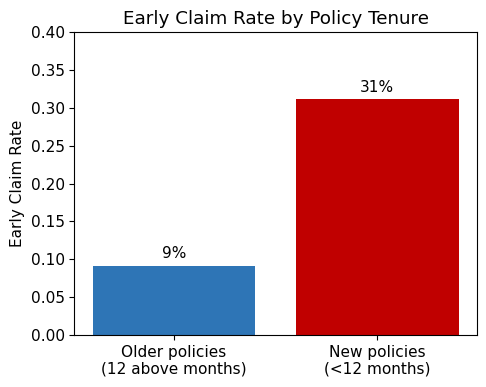

In [40]:
# Early claim rate by policy tenure
fig, ax = plt.subplots(figsize=(5, 4))
g = df_features.groupby('EarlyTenure')['EarlyClaimFlag'].mean()

# EarlyTenure: 0 = older policies (12 above months), 1 = new policies (<12 months)
labels = ['Older policies\n(12 above months)', 'New policies\n(<12 months)']

bars = ax.bar(labels, g.values, color=['#2e75b6', '#c00000'])
ax.set_title('Early Claim Rate by Policy Tenure')
ax.set_ylabel('Early Claim Rate')
ax.set_ylim(0, 0.4)

for bar, v in zip(bars, g.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.0%}', ha='center')

plt.tight_layout()
plt.savefig('chart_tenure.png', dpi=150)
plt.show()

Early Claim Rate by Policy Tenure.

Policies that have been active for less than 12 months have an early claim rate of 31%, indicating that almost one in three new policies(less than 12 months) results in an early claim.
Policies that have been active for 12 months and above have a much lower early claim rate of 9%, showing that early claims are far less common once a policy has matured beyond its first year.
The early claim rate for new policies is about 3.4 times higher than for established policies, making early policy tenure a clear high-risk period.
This pattern suggests that the first 12 months of a policy carry significantly higher risk, likely driven by anti-selection and incomplete risk filtering at onboarding.

Conclusion
Early claim risk is concentrated in the first 12 months of policy life. New policies represent a higher-risk segment and should be prioritised for stronger underwriting checks and stricter early-life waiting periods or exclusions.


In [41]:
df.to_csv("df_features_modeling.csv")

In [42]:
df_features.groupby(['Channel', 'Ageband'])['EarlyClaimFlag'].agg(['mean', 'count'])

C:\Users\HP\AppData\Local\Temp\ipykernel_13084\3647500533.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_features.groupby(['Channel', 'Ageband'])['EarlyClaimFlag'].agg(['mean', 'count'])


mean  count
Channel       Ageband                 
Agent         18-30    0.064516     31
              31-45    0.052632     57
              46-60    0.393939     66
              60+      1.000000     27
Bancassurance 18-30    0.000000     42
              31-45    0.000000     36
              46-60    0.024390     41
              60+      0.121212     33
Digital       18-30    0.000000     31
              31-45    0.000000     56
              46-60    0.018868     53
              60+      0.185185     27

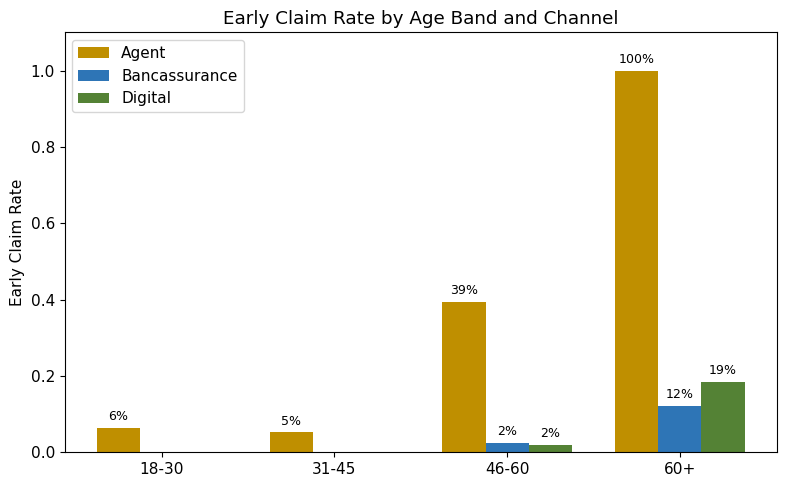

In [43]:

fig, ax = plt.subplots(figsize=(8, 5))

# Compute the interaction table
interaction = df_features.groupby(['Channel', 'Ageband'], observed=True)['EarlyClaimFlag'].mean().unstack()

age_bands = interaction.columns.tolist()
x = np.arange(len(age_bands))
width = 0.25

colors = {'Agent': '#bf8f00', 'Bancassurance': '#2e75b6', 'Digital': '#548235'}

for i, channel in enumerate(['Agent', 'Bancassurance', 'Digital']):
    values = interaction.loc[channel].values
    offset = (i - 1) * width
    bars = ax.bar(x + offset, values, width, label=channel, color=colors[channel])
    for bar, v in zip(bars, values):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.0%}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(age_bands)
ax.set_ylabel('Early Claim Rate')
ax.set_title('Early Claim Rate by Age Band and Channel')
ax.set_ylim(0, 1.1)
ax.legend()

plt.tight_layout()
plt.savefig('chart_interaction.png', dpi=150)
plt.show()

Interpretation.

The results show that age and sales channel together have a much stronger effect on early claims than either factor alone.

Agent channel shows the highest risk. Early-claim rates increase with age, rising from 6.5% (18–30) and 5.3% (31–45) to 39.4% (46–60). For customers aged 60 and above, the rate reaches 100%, meaning all 27 policies in this group resulted in an early claim.

Bancassurance and Digital channels remain relatively low risk. Although early-claim rates increase with age, they remain much lower than those observed in the Agent channel. For customers aged 60+, the rates are 12.1% for Bancassurance and 18.5% for Digital.

The highest-risk segment is customers aged 60+ who purchased through Agents. The overall high risk observed in the Agent channel is largely driven by this age group. The Agent channel's 46–60 age group is also high risk, with an early-claim rate of 39.4%.

The 60+ Agent group contains 27 policies. While this is a relatively small subgroup, all 27 policies resulted in an early claim, making it a clear area of concern.

Conclusion.

The findings suggest that policies sold through Agents to customers aged 60 and above require closer attention. Enhanced underwriting measures, such as additional medical assessments or stricter policy reviews, may help reduce the risk of early claims in this segment.

=== Lapse rate by ProductType ===
                 mean  count
ProductType                 
Endowment    0.301282    156
Term Life    0.404762    168
Whole Life   0.363636    176

=== Lapse rate by ProductType and Channel ===
                               mean  count
ProductType Channel                       
Endowment   Agent          0.190476     63
            Bancassurance  0.232558     43
            Digital        0.500000     50
Term Life   Agent          0.419355     62
            Bancassurance  0.245283     53
            Digital        0.547170     53
Whole Life  Agent          0.232143     56
            Bancassurance  0.285714     56
            Digital        0.546875     64

=== Lapse rate pivot table (rows=ProductType, cols=Channel) ===
Channel      Agent  Bancassurance  Digital
ProductType                               
Endowment    0.190          0.233    0.500
Term Life    0.419          0.245    0.547
Whole Life   0.232          0.286    0.547


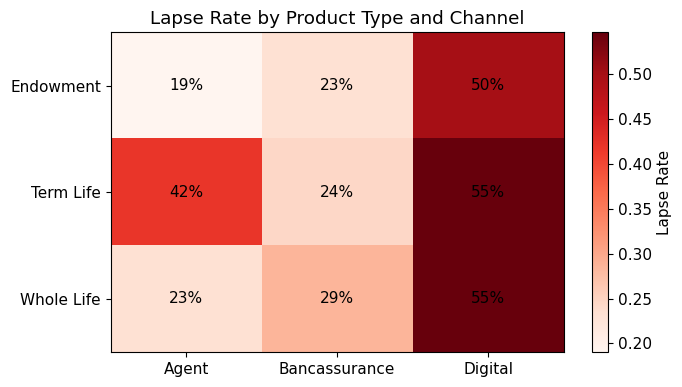

In [44]:
# %% [markdown]
# ## Lapse risk by Product Type and Channel
#
# Checks whether lapse rate varies by product type, and whether certain
# product-channel combinations are particularly risky (e.g. Term Life
# sold through Digital).

# %%
# Lapse rate by ProductType alone
print("=== Lapse rate by ProductType ===")
print(df_features.groupby('ProductType')['LapseFlag'].agg(['mean', 'count']))

# %%
# Lapse rate by ProductType AND Channel together
print("\n=== Lapse rate by ProductType and Channel ===")
print(df_features.groupby(['ProductType', 'Channel'])['LapseFlag'].agg(['mean', 'count']))

# %%
# Pivot table view - easier to scan for "hot spot" combinations
pivot = df_features.groupby(['ProductType', 'Channel'])['LapseFlag'].mean().unstack().round(3)
print("\n=== Lapse rate pivot table (rows=ProductType, cols=Channel) ===")
print(pivot)

# %%
# Optional: visualize as a heatmap
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, cmap='Reds', aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title('Lapse Rate by Product Type and Channel')

# Annotate each cell with its value
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i,j]:.0%}', ha='center', va='center', color='black')

plt.colorbar(im, label='Lapse Rate')
plt.tight_layout()
plt.savefig('chart_product_channel.png', dpi=150)
plt.show()

### Interpretation

This heatmap shows that policy lapse rates vary significantly across both product types and sales channels, with the Digital channel consistently recording the highest rates.

Digital channel has the highest lapse rates across all products.Lapse rates are 50.0% for Endowment, 54.7% for Term Life, and 55.0% for Whole Life. This indicates that the higher lapse risk is not linked to a specific product but is a broader issue affecting policies sold through the Digital channel.

Term Life is the highest-risk product. With an overall lapse rate of 40.5%, Term Life performs worse than the other products. The risk is particularly high when sold through Agents (41.9%) and Digital channels (54.7%), while Bancassurance records a much lower rate of 24.5%.

Term Life sold through Digital is the riskiest combination. At 54.7%, more than half of these policies lapse, making it the highest lapse rate among all product-channel combinations.

Endowment sold through Agents performs best.With a lapse rate of 19.0%, this combination has the lowest lapse rate in the table and demonstrates stronger policy retention than any other segment.

Bancassurance is the most stable channel.Lapse rates remain relatively low and consistent across all products, ranging from 23% to 29%. This suggests that Bancassurance is the most effective channel for retaining policyholders and may provide useful practices that could be applied to other channels.

Conclusion.

The results suggest that efforts to reduce policy lapses should focus primarily on the Digital channel, particularly for Term Life products. At the same time, the strong performance of Bancassurance and Agent-sold Endowment policies could provide insights into customer engagement and retention practices that may help improve performance in higher-risk segments.


In [45]:
# Premium band and lapse, early claim flag( Does policy size matter)
df_features.groupby('Premiumband', observed=True)[['LapseFlag','EarlyClaimFlag']].agg(['mean','count'])

LapseFlag       EarlyClaimFlag      
                  mean count           mean count
Premiumband                                      
Micro <=500K  0.196429    56       0.178571    56
Low 500K-1M   0.363636    77       0.051948    77
Mid 1M-2M     0.225641   195       0.123077   195
High 2M-3M    0.558140   172       0.180233   172

             LapseFlag       EarlyClaimFlag      
                  mean count           mean count
Premiumband                                      
Micro <=500K  0.196429    56       0.178571    56
Low 500K-1M   0.363636    77       0.051948    77
Mid 1M-2M     0.225641   195       0.123077   195
High 2M-3M    0.558140   172       0.180233   172


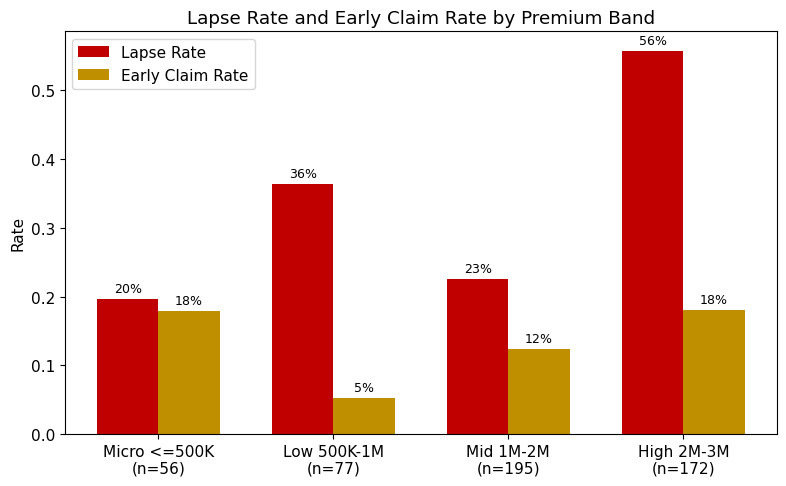

In [46]:

# %%
# Get the table with mean and count
result = df_features.groupby('Premiumband', observed=True)[['LapseFlag','EarlyClaimFlag']].agg(['mean','count'])
print(result)

# %%
# Extract means and counts for plotting
means = result.xs('mean', axis=1, level=1)
counts = result.xs('count', axis=1, level=1)['LapseFlag']  # count is same across both columns

labels = means.index.astype(str)
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, means['LapseFlag'], width, label='Lapse Rate', color='#c00000')
b2 = ax.bar(x + width/2, means['EarlyClaimFlag'], width, label='Early Claim Rate', color='#bf8f00')

ax.set_xticks(x)
ax.set_xticklabels([f'{l}\n(n={c})' for l, c in zip(labels, counts)])
ax.set_ylabel('Rate')
ax.set_title('Lapse Rate and Early Claim Rate by Premium Band')
ax.legend()

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.0%}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('chart_premiumband.png', dpi=150)
plt.show()

Interpretation

This analysis shows that premium size is strongly associated with policy lapse rates, with higher-premium policies generally more likely to lapse.

High-premium policies have the highest lapse risk. The High premium band (UGX 2M–3M) records a lapse rate of 55.8%, which is substantially higher than the portfolio average of 35.8% and the highest among all premium bands. This suggests that customers with larger premium commitments are more likely to discontinue their policies.

Micro-premium policies are the most stable segment. The Micro premium band (<=500K) has the lowest lapse rate at 20%.This may be attributed to the small customer group of these micro premium policy holders (n=56).

In terms of stability,the Mid premium band(1M-2M) is more stable with a relatively low lapse rate of 23% and low early claim rate of 12%. This is because of it holds the largets number of policy holders (n=195) but is able to have lower lapse rate and lower early claim rate. This indicates that this segment has stronger policy retention and forms a stable core of the portfolio.

Lapses have a greater impact on premium revenue. The high lapse rate among high-premium policies helps explain why lapsed policies account for 41.4% of total premium value but only 35.8% of policy count. Higher-value policies are more likely to lapse and yet they are the ones that contribute more premium revenue. This calss for further investigation in this matter

Early claim rates follow a different pattern. Early-claim rates range from 5.2% in the Low premium band (UGX 500K–1M) to to 12% in Mid premium band(1M-2M), and to about 18% in both the Micro(<=500K) and High premium band(2M-3M). Unlike lapse rates, early claims do not show a clear increase with premium size.

Low-premium policies show high lapse but low claim risk. The Low premium band has a relatively high lapse rate (36.4%) but the lowest early-claim rate (5.2%). This suggests that while customers in this segment are more likely to discontinue their policies, those who remain active are less likely to submit early claims.

Conclusion.

Retention efforts should focus on High-premium policyholders, where both the likelihood of lapse and the resulting revenue loss are greatest. At the same time, understanding the characteristics of the Mid-premium segment may provide insights into practices that support stronger customer retention which can be applied to the high premium high risk policyholders.

RiskCategory
0_0    277
1_0    154
0_1     44
1_1     25
Name: count, dtype: int64


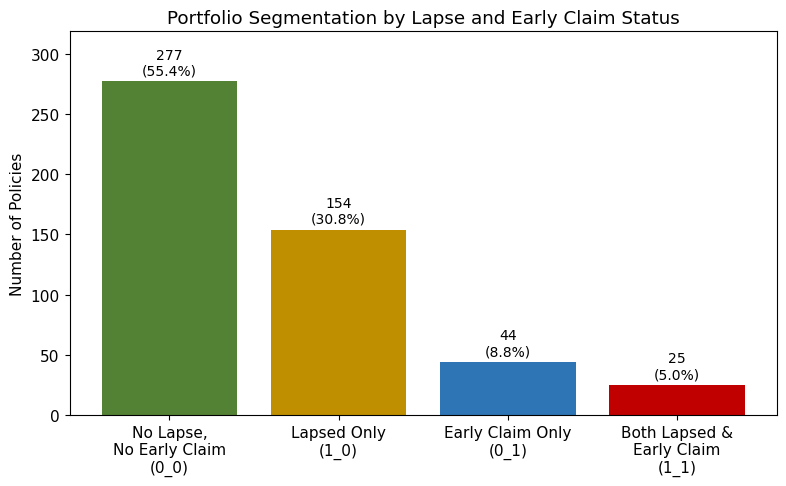

In [48]:

# Build the combined risk category
df_features['RiskCategory'] = df_features['LapseFlag'].astype(str) + '_' + df_features['EarlyClaimFlag'].astype(str)
counts_series = df_features['RiskCategory'].value_counts()
print(counts_series)

# Map codes to readable labels (order matters - match your value_counts order)
label_map = {
    '0_0': 'No Lapse,\nNo Early Claim\n(0_0)',
    '1_0': 'Lapsed Only\n(1_0)',
    '0_1': 'Early Claim Only\n(0_1)',
    '1_1': 'Both Lapsed &\nEarly Claim\n(1_1)'
}

labels = [label_map[k] for k in counts_series.index]
counts = counts_series.values
colors = ['#548235', '#bf8f00', '#2e75b6', '#c00000']

total = counts.sum()
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, counts, color=colors[:len(labels)])

ax.set_ylabel('Number of Policies')
ax.set_title('Portfolio Segmentation by Lapse and Early Claim Status')
ax.set_ylim(0, max(counts) * 1.15)

for bar, c in zip(bars, counts):
    pct = c / total
    ax.text(bar.get_x() + bar.get_width()/2, c + max(counts)*0.02, f'{c}\n({pct:.1%})', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart_risk_category.png', dpi=150)
plt.show()

Interpretation

The portfolio can be divided into four groups based on whether a policy lapsed and whether it experienced an early claim.

No lapse, no early claim (0_0) accounts for 277 policies (55.4%), making it the largest segment. These policyholders remained active and did not submit an early claim. This represents the healthiest portion of the portfolio and serves as a useful benchmark for understanding the characteristics of lower-risk customers.

Lapsed, no early claim (1_0) includes 154 policies (30.8%). This is the largest risk segment in the portfolio. These customers discontinued their policies without making an early claim, suggesting that retention challenges, such as affordability issues or missed premium payments, may be key drivers of risk in this group.

No lapse, early claim (0_1) comprises 44 policies (8.8%). These policyholders remained active but submitted an early claim. This segment is primarily associated with underwriting risk, as the policies generated claims despite being retained.

Lapsed and early claim (1_1) represents 25 policies (5.0%), making it the smallest segment. Although relatively small, this group combines both major risk outcomes—early claims and policy lapses. As a result, it may have a disproportionate impact on profitability and warrants closer investigation.

Implication

The findings indicate that portfolio risk is driven mainly by two distinct issues: policy lapses and early claims. The largest risk challenge is the lapsed-without-claim segment (30.8%), highlighting the importance of improving customer retention. Meanwhile, the early-claim segments clients point to underwriting and risk-selection concerns. The small group experiencing both outcomes (5.0%) should be prioritized for further analysis, as it represents customers who generate costs through claims while also contributing to lost premium income through lapses.

                                         mean  count
PaymentFrequency MissedPaymentsflag                 
Annual           0                   0.046053    152
                 1                   0.732143    112
Monthly          0                   0.046875    128
                 1                   0.777778    108


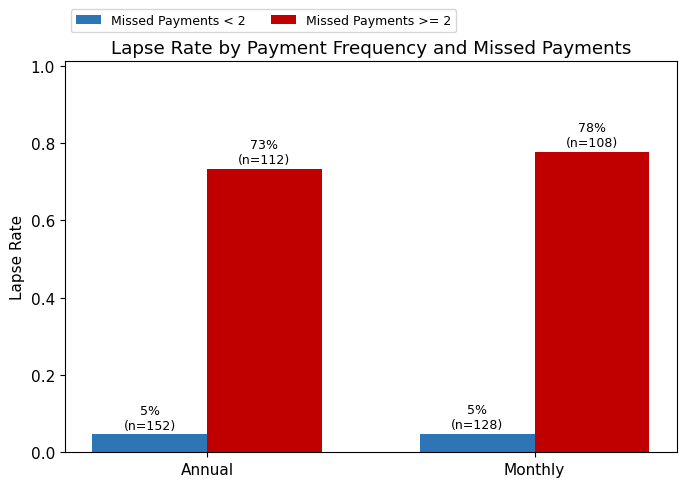

In [50]:

# Lapse rate by payment frequency and missed  payments
result = df_features.groupby(['PaymentFrequency','MissedPaymentsflag'])['LapseFlag'].agg(['mean','count'])
print(result)

# %%
pivot_mean = df_features.groupby(['PaymentFrequency','MissedPaymentsflag'])['LapseFlag'].mean().unstack()
pivot_count = df_features.groupby(['PaymentFrequency','MissedPaymentsflag'])['LapseFlag'].count().unstack()

labels = pivot_mean.index.tolist()
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
b1 = ax.bar(x - width/2, pivot_mean[0], width, label='Missed Payments < 2', color='#2e75b6')
b2 = ax.bar(x + width/2, pivot_mean[1], width, label='Missed Payments >= 2', color='#c00000')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Lapse Rate')
ax.set_title('Lapse Rate by Payment Frequency and Missed Payments')
ax.set_ylim(0, max(pivot_mean.max()) * 1.3)
ax.legend(loc='upper left', bbox_to_anchor=(0, 1.15), ncol=2, fontsize=9)

for bars, col in [(b1, 0), (b2, 1)]:
    for bar, freq in zip(bars, labels):
        h = bar.get_height()
        c = pivot_count.loc[freq, col]
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.015, f'{h:.0%}\n(n={c})', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('chart_paymentfreq.png', dpi=150)
plt.show()

### Interpretation

This analysis shows that missed payments are a much stronger predictor of policy lapse than payment frequency.

Lapse rates are very low when less than two payments are missed.Annual payers with less than than two missed payments have a lapse rate of 4.6%, while Monthly payers with less than two missed payments have a nearly identical rate of 4.7%. This indicates that customers who maintain their payment schedules are unlikely to lapse regardless of payment frequency.

Lapse rates increase sharply after two or more missed payments.Among Annual payers, the lapse rate rises to 73.2%, while Monthly payers record a lapse rate of 77.8%. In both cases, approximately three out of every four policies lapse once two or more payments are missed.

Missed payments are the key driver of lapse risk.The increase in lapse rates from less than two missed payments to two or more missed payments is substantial for both Annual payers (4.6% to 73.2%) and Monthly payers (4.7% to 77.8%). In contrast, the difference between Annual and Monthly payment frequencies within the same missed-payment category is relatively small.

Monthly payers show slightly higher lapse risk after missed payments.Although the difference is modest, Monthly payers with two or more missed payments have a somewhat higher lapse rate than Annual payers (77.8% versus 73.2%). This suggests that missed monthly payments may be a slightly stronger indicator of financial strain, though the overall pattern remains very similar across both payment frequencies.

### Implication

The findings confirm that missed payments are the primary early-warning indicator of policy lapse, regardless of whether customers pay annually or monthly. Customers with less than two missed payments have very low lapse rates, while those with two or more missed payments face a high risk of lapse. This suggests that retention efforts should focus on customers once they reach the two-missed-payment threshold, rather than developing separate strategies for different payment frequencies. Such an approach would simplify intervention programs while targeting the strongest predictor of lapse in the portfolio.


In [51]:
lapsed = df_features[df_features['LapseFlag']==1]
print(lapsed['MissedPayments'].value_counts().sort_index())
salvageable_premium = lapsed[lapsed['MissedPayments']==2]['Premium'].sum()
print(f"Premium in '2 missed payments' (salvageable) group: {salvageable_premium:,.0f}")

MissedPayments
1    13
2    70
3    57
4    22
5    12
6     4
8     1
Name: count, dtype: int64
Premium in '2 missed payments' (salvageable) group: 140,521,026


MissedPayments
1    13
2    70
3    57
4    22
5    12
6     4
8     1
Name: count, dtype: int64
MissedPayments
1     33252575
2    140521026
3     91375165
4     36861163
5     22806400
6      6322411
8       355683
Name: Premium, dtype: int64

Premium in '2 missed payments' (salvageable) group: 140,521,026


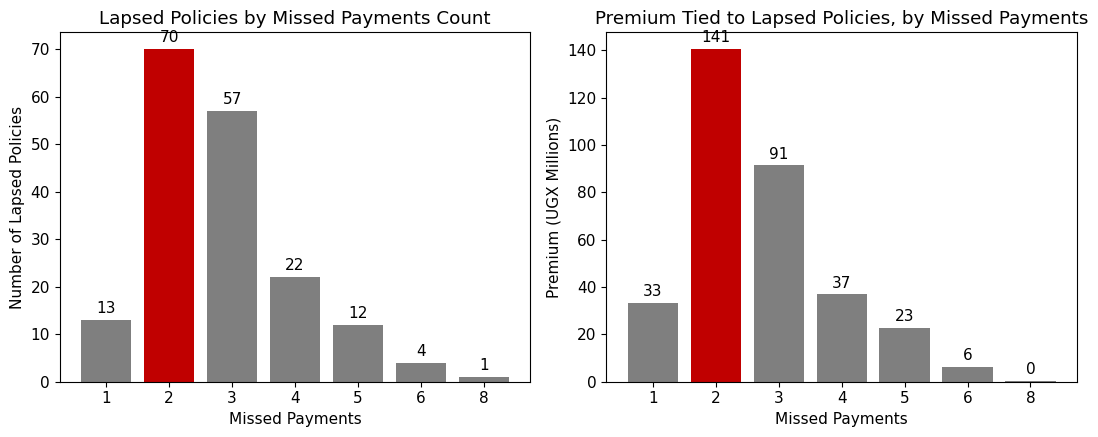

In [52]:

# Earliest recovery point to manage lapse rate
lapsed = df_features[df_features['LapseFlag']==1]

counts = lapsed['MissedPayments'].value_counts().sort_index()
print(counts)

premium_by_missed = lapsed.groupby('MissedPayments')['Premium'].sum()
print(premium_by_missed)

salvageable_premium = lapsed[lapsed['MissedPayments']==2]['Premium'].sum()
print(f"\nPremium in '2 missed payments' (salvageable) group: {salvageable_premium:,.0f}")

# %%
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Highlight the "2 missed payments" group in red - this is the "salvageable" segment
colors = ['#c00000' if m == 2 else '#7f7f7f' for m in counts.index]
bars1 = axes[0].bar(counts.index.astype(str), counts.values, color=colors)
axes[0].set_xlabel('Missed Payments')
axes[0].set_ylabel('Number of Lapsed Policies')
axes[0].set_title('Lapsed Policies by Missed Payments Count')
for bar, v in zip(bars1, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v + max(counts)*0.02, str(v), ha='center')

colors2 = ['#c00000' if m == 2 else '#7f7f7f' for m in premium_by_missed.index]
bars2 = axes[1].bar(premium_by_missed.index.astype(str), premium_by_missed.values/1e6, color=colors2)
axes[1].set_xlabel('Missed Payments')
axes[1].set_ylabel('Premium (UGX Millions)')
axes[1].set_title('Premium Tied to Lapsed Policies, by Missed Payments')
for bar, v in zip(bars2, premium_by_missed.values/1e6):
    axes[1].text(bar.get_x()+bar.get_width()/2, v + max(premium_by_missed)/1e6*0.02, f'{v:,.0f}', ha='center')

plt.tight_layout()
plt.savefig('chart_salvageable.png', dpi=150)
plt.show()

### Interpretation

This breakdown shows that the "2 missed payments” group is the most important segment for both risk and recovery planning.

The 2 missed payments group is the largest and most valuable lapsed segment. It contains 70 policies, representing UGX 140.5M in premium, which is the highest total premium among all missed-payment categories. It is larger than the 3-missed-payments group (57 policies, UGX 91.4M) in both policy count and value.

This group represents a key intervention opportunity.At the 2-missed-payment stage, the lapse rate is 56.5%, meaning nearly half of these policies are still recoverable. This makes it a critical decision point where timely action can prevent a large share of future lapses.

UGX 140.5M is the main recovery target.This accounts for about 42% of all premium tied to lapsed policies, making it the single biggest opportunity for a retention or payment-recovery strategy.

The 1 missed payment group is an early warning stage.It includes 13 policies worth UGX 33.3M, and although smaller in size, it represents the earliest point where intervention could prevent progression to higher-risk stages.

The 3+ missed payments groups represent mostly lost cases.Together, they account for 96 policies and UGX 157.7M in premium, and from earlier results, these groups show near-certain lapse outcomes. This suggests that recovery efforts at this stage are likely to have limited impact.

### Implication

The results clearly show that the 2-missed-payment threshold is the most effective intervention point. It contains the largest share of lapsed premium (UGX 140.5M) and still has a meaningful chance of retention. Strengthening automated follow-ups, payment reminders, or agent outreach at this stage would likely deliver the highest return. In contrast, efforts after three or more missed payments are likely to have limited effectiveness and should be deprioritized in favour of earlier intervention.


In [54]:
# costs of early claims by channel, ageband and tenure
# Cost of early claims by Channel
early = df_features[df_features['EarlyClaimFlag']==1]
print(early.groupby('Channel')['ClaimAmount'].agg(['sum','mean','count']))

# Cost of early claims by Age band
print(early.groupby('Ageband', observed=True)['ClaimAmount'].agg(['sum','mean','count']))

# Cost of early claims by Tenure (new vs old policies)
print(early.groupby('EarlyTenure')['ClaimAmount'].agg(['sum','mean','count']))

                     sum          mean  count
Channel                                      
Agent          716854709  1.235956e+07     58
Bancassurance   50471186  1.009424e+07      5
Digital         88845110  1.480752e+07      6
               sum          mean  count
Ageband                                
18-30     34723096  1.736155e+07      2
31-45     29913437  9.971146e+06      3
46-60    349160031  1.247000e+07     28
60+      442374441  1.228818e+07     36
                   sum          mean  count
EarlyTenure                                
0            467975328  1.299931e+07     36
1            388195677  1.176351e+07     33


Interpretation

These breakdowns consistently show where the UGX 856.2M in early-claim payouts is concentrated, and the pattern aligns strongly across channel, age, and tenure.

1. Cost is overwhelmingly concentrated in the Agent channel.
Agent accounts for UGX 716.9M (83.7%) from 58 policies, making it the dominant driver of early-claim cost. Bancassurance and Digital together contribute only UGX 139.3M (16.3%) from 11 policies. This difference is not driven by larger claim sizes — average claim values are broadly similar across channels — but by a much higher number of claims in the Agent channel.

2. Older age groups drive nearly all the cost.
The 46–60 group (UGX 349.2M) and 60+ group (UGX 442.4M) together account for UGX 791.5M (92.5%) of total cost. Younger age bands contribute only a small fraction. As with channels, the concentration is due to higher claim frequency rather than higher claim amounts per case.

3. Tenure shows a more balanced split than expected.
Although policies under 12 months have a much higher early-claim rate (31.1% while 9.1% for policies 12 months and above), total cost is relatively evenly distributed:

12 and above months: UGX 468.0M (36 policies)
<12 months: UGX 388.2M (33 policies)

This occurs because the portfolio has far more long-tenure policies overall, meaning both groups generate a similar number of claims and therefore similar total cost. Tenure is therefore a strong risk indicator but not the main driver of total cost.

Overall business insight

Early claims affect only 13.8% of policies, but the resulting UGX 856.2M cost is highly concentrated, mainly in Agent channel policies (83.7%) and customers aged 46+ (92.5%). Importantly, this concentration is driven by how often claims occur, not how large they are, since claim sizes remain fairly consistent across segments (about UGX 10–17M).

In [55]:
# Financial constrain of early claims payment payouts
early = df_features[df_features['EarlyClaimFlag']==1].copy()
early['ClaimToPremiumRatio'] = early['ClaimAmount'] / early['Premium']
print(early['ClaimToPremiumRatio'].describe())

count    69.000000
mean     11.992030
std      13.074511
min       1.949955
25%       4.736291
50%       7.178237
75%      12.313054
max      60.141016
Name: ClaimToPremiumRatio, dtype: float64


**Interpretation**

This metric shows the financial intensity of early claims by comparing claim payouts to the annual premium paid for each policy.

Early claims are extremely expensive relative to premiums. On average, the claim-to-premium ratio is 11.99, meaning insurers pay about 12 times the annual premium for each early-claim policy. Even the minimum observed value is 1.95, showing that every early claim costs at least nearly twice the annual premium collected.

Most early claims fall in a very high-cost range. The median ratio is 7.2, meaning half of all early claims cost at least seven times the annual premium. The interquartile range (4.7 to 12.3) shows that most claims sit well above breakeven levels.

Extreme outliers drive very high losses. The maximum ratio reaches 60.1, meaning some claims cost more than 60 times the annual premium. These rare cases represent severe financial exposure.

Practical meaning. For example, a policy with an annual premium of UGX 1.5M could generate a typical early claim payout of around UGX 10.8M (7.2 times), and in extreme cases up to UGX 90M (60 times). This highlights how small premium inflows can translate into very large early losses.

**Business implication**

Early claims are not just frequent in certain segments,they are financially disproportionate events, where payouts far exceed premiums collected, often before the policy has matured. This explains why early claims contribute heavily to total losses despite affecting a minority of policies (13.8%). It reinforces the need for strong upfront underwriting controls, waiting periods, and risk screening, since once an early claim occurs, the financial impact is consistently severe regardless of customer segment.

In [58]:
# The potential premium that could be retained if digital's lapse rate were improved to match Bancassurance's level.
digital = df_features[df_features['Channel']=='Digital']
current_lapsed_premium = digital[digital['LapseFlag']==1]['Premium'].sum()
target_lapse_rate = 0.257  # Bancassurance rate
hypothetical_lapsed_premium = digital['Premium'].sum() * target_lapse_rate
print(f"Current Digital lapsed premium: {current_lapsed_premium:,.0f}")
print(f"If Digital matched Bancassurance rate: {hypothetical_lapsed_premium:,.0f}")
print(f"Potential premium saved: {current_lapsed_premium - hypothetical_lapsed_premium:,.0f}")

Current Digital lapsed premium: 151,858,756
If Digital matched Bancassurance rate: 66,099,542
Potential premium saved: 85,759,214



### Interpretation

This scenario estimates the financial impact of improving retention in the Digital channel by benchmarking it against the best-performing channel (Bancassurance).

Digital channel underperforms significantly as it has UGX 151.9M in premium tied up in lapsed policies, driven by a 53.3% lapse rate. This represents the current level of avoidable loss in this channel.

The benchmark scenario shows a much lower loss level.If Digital performed at the same level as Bancassurance (25.7% lapse rate), the lapsed premium would drop to about UGX 66.1M.

The difference between the two scenarios is approximately UGX 85.8M, meaning more than half ( approximately 56%) of the current lapsed premium in Digital could potentially be avoided under improved performance.

### Business implication

The results support prioritising Digital-channel retention initiatives, particularly around onboarding quality, affordability screening, and early-warning interventions (such as missed-payment triggers). Even partial movement toward Bancassurance performance would translate into meaningful premium retention gains.
